In [72]:
import os, random
from pathlib import Path

from PIL import Image
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2

In [60]:
FRAMES_TO_STACK = 16
DOWNSAMPLING_SIZE = 256
CROP_SIZE = 224
REMOVE_BACKGROUND = False

N_AUG = 2
COL_JITTER_BR = 0.2

In [3]:
BASE_DIR = Path(r"/Users/kotpr/Documents/Study/TUDresden/Research Project/grasp_labeller_lasr/dataset")

In [4]:
finger_names = ["thumb", "index", "middle", "ring"]

In [ ]:
tested_iteration = BASE_DIR / random.sample(os.listdir(BASE_DIR), 1)[0]

In [ ]:
phase_data_path = tested_iteration / "grasp/grasp_phases.csv"

camera_meta_paths = {
    finger: tested_iteration / f"opentouch/digit360/{finger}/camera/camera.csv"
    for finger in finger_names
}
frames_paths = {
    finger: tested_iteration / f"opentouch/digit360/{finger}/camera/frames"
    for finger in finger_names
}

In [6]:
missing_fingers = [
    finger
    for finger in finger_names
    if not camera_meta_paths[finger].exists() or not frames_paths[finger].exists()
]
if missing_fingers:
    raise FileNotFoundError(f"Missing camera data for fingers: {missing_fingers}")

In [7]:
frames_meta = {
    finger: pd.read_csv(camera_meta_paths[finger]).sort_values(by="time_perf", axis=0)
    for finger in finger_names
}
phase_data = pd.read_csv(phase_data_path)

In [25]:
last_frame_paths = {
    finger: [frames_paths[finger] / filename for filename in frames_meta[finger]["filename"].iloc[-FRAMES_TO_STACK:]]
    for finger in finger_names
}

lift_start_time = phase_data.loc[
    phase_data["phase"] == "lift",
    "perf_time",
].values[0]

lift_beginning_paths = {
    finger: [
        frames_paths[finger] / filename
        for filename in frames_meta[finger]
        .loc[frames_meta[finger]["time_perf"] >= lift_start_time, "filename"]
        .iloc[:FRAMES_TO_STACK]
    ]
    for finger in finger_names
}

first_frame_paths = {
    finger: frames_paths[finger] / frames_meta[finger]["filename"].iloc[0]
    for finger in finger_names
}

In [27]:
def load_rgb_frame(path):
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

finger_last_frames = {
    finger: np.stack([load_rgb_frame(path) for path in paths], axis=0)
    for finger, paths in last_frame_paths.items()
}

finger_last_images = {
    finger: np.round(frames.astype(np.float32).mean(axis=0)).astype(np.uint8)
    for finger, frames in finger_last_frames.items()
}

finger_lift_beg_frames = {
    finger: np.stack([load_rgb_frame(path) for path in paths], axis=0)
    for finger, paths in lift_beginning_paths.items()
}

finger_lift_beg_images = {
    finger: np.round(frames.astype(np.float32).mean(axis=0)).astype(np.uint8)
    for finger, frames in finger_lift_beg_frames.items()
}

# Backward-compatible alias for cells below that still inspect a single image.
img = finger_last_images["index"]

In [28]:
finger_backgrounds = {
    finger: load_rgb_frame(path)
    for finger, path in first_frame_paths.items()
}

# Backward-compatible alias for cells below that still inspect a single image.
background = finger_backgrounds["index"]

In [ ]:
class RemoveBackground:
    def __init__(self, bgr):
        self.bgr = bgr

    def __call__(self, img):
        assert img.shape == self.bgr.shape
        return img - self.bgr

class Cv2ToRgb:
    def __call__(self, img, *args):
        # img: BGR numpy array from cv2
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

class Cv2Resize:
    def __init__(self, size, interpolation=cv2.INTER_AREA):
        self.size = size

        self.interpolation = interpolation

    def __call__(self, img, _):
        # img: numpy array, HWC, RGB    
        return cv2.resize(img, self.size, interpolation=self.interpolation)

In [ ]:
augmentations = [
    v2.Compose([
        v2.RandomCrop(CROP_SIZE),
        v2.ColorJitter(brightness=COL_JITTER_BR)
    ]),
    v2.RandomCrop(CROP_SIZE),
    v2.Compose([
        v2.CenterCrop((CROP_SIZE, CROP_SIZE)),
        v2.ColorJitter(brightness=COL_JITTER_BR)
    ])
]

In [ ]:
class TactileDataset(Dataset):
    def __init__(
        self,
        samples,
        train_transform=None,
        val_transform=None,
        n_aug_copies=1,
        include_original=True,
        train=True,
    ):
        self.samples = samples
        self.train_transform = train_transform
        self.val_transform = val_transform
        self.n_aug_copies = n_aug_copies
        self.include_original = include_original
        self.train = train

        if self.train:
            self.copies_per_image = n_aug_copies + int(include_original)
        else:
            self.copies_per_image = 1

    def __len__(self):
        return len(self.samples) * self.copies_per_image

    def __getitem__(self, index):
        real_index = index // self.copies_per_image
        copy_index = index % self.copies_per_image

        sample = self.samples[real_index]

        image = self._load_iteration(sample["iter_path"])
        label = sample["label"]

        if not self.train:
            image = self.val_transform(image)
            return image, label

        if self.include_original and copy_index == 0:
            image = self.val_transform(image)
        else:
            image = self.train_transform(image)

        return image, label

    def load_iteration(self, iteration_path: Path):
        phase_data_path = iteration_path / "grasp/grasp_phases.csv"
        camera_meta_paths = {
            finger: iteration_path / f"opentouch/digit360/{finger}/camera/camera.csv"
            for finger in finger_names
        }
        frames_paths = {
            finger: iteration_path / f"opentouch/digit360/{finger}/camera/frames"
            for finger in finger_names
        }
        missing_fingers = [
            finger
            for finger in finger_names
            if not camera_meta_paths[finger].exists() or not frames_paths[finger].exists()
        ]
        if missing_fingers:
            raise FileNotFoundError(f"Missing camera data for fingers: {missing_fingers}")
        frames_meta = {
            finger: pd.read_csv(camera_meta_paths[finger]).sort_values(by="time_perf", axis=0)
            for finger in finger_names
        }
        phase_data = pd.read_csv(phase_data_path)
        
        last_frame_paths = {
            finger: [frames_paths[finger] / filename for filename in frames_meta[finger]["filename"].iloc[-FRAMES_TO_STACK:]]
            for finger in finger_names
        }

        lift_start_time = phase_data.loc[
            phase_data["phase"] == "lift",
            "perf_time",
        ].values[0]

        lift_beginning_paths = {
            finger: [
                frames_paths[finger] / filename
                for filename in frames_meta[finger]
                .loc[frames_meta[finger]["time_perf"] >= lift_start_time, "filename"]
                .iloc[:FRAMES_TO_STACK]
            ]
            for finger in finger_names
        }

        first_frame_paths = {
            finger: frames_paths[finger] / frames_meta[finger]["filename"].iloc[0]
            for finger in finger_names
        }

        finger_backgrounds = {
            finger: load_rgb_frame(path)
            for finger, path in first_frame_paths.items()
        }

        finger_last_frames = {
            finger: np.stack([load_rgb_frame(path) for path in paths], axis=0)
            for finger, paths in last_frame_paths.items()
        }

        finger_last_images = {
            finger: np.round(frames.astype(np.float32).mean(axis=0)).astype(np.uint8)
            for finger, frames in finger_last_frames.items()
        }

        finger_lift_beg_frames = {
            finger: np.stack([load_rgb_frame(path) for path in paths], axis=0)
            for finger, paths in lift_beginning_paths.items()
        }

        finger_lift_beg_images = {
            finger: np.round(frames.astype(np.float32).mean(axis=0)).astype(np.uint8)
            for finger, frames in finger_lift_beg_frames.items()
        }

        label = pd.read.csv(iteration_path / "grasp/grasp_label.csv")
        label = label.loc[label["method" == "manual"], "label"].values[0]

        return ({
            finger: {
                "background": finger_backgrounds[finger],
                "lift_start": finger_lift_beg_images[finger],
                "lift_end": finger_last_images[finger]
            } for finger in finger_names
        }, label)

    def _load_image(self, path):
        img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise FileNotFoundError(path)
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [74]:
preprocess_transform = v2.Compose([
    RemoveBackground(background) if REMOVE_BACKGROUND else v2.Identity(),
    Cv2Resize((DOWNSAMPLING_SIZE, DOWNSAMPLING_SIZE), interpolation=cv2.INTER_AREA),
    v2.ToImage(),
    v2.CenterCrop((CROP_SIZE, CROP_SIZE)),
])

In [ ]:
preprocess_aug_transform = v2.Compose([
    RemoveBackground(background) if REMOVE_BACKGROUND else v2.Identity(),
    Cv2Resize((DOWNSAMPLING_SIZE, DOWNSAMPLING_SIZE), interpolation=cv2.INTER_AREA),
    v2.ToImage(),
    v2.RandomCrop(CROP_SIZE),
    v2.ColorJitter(brightness=COL_JITTER_BR)
])

In [ ]:
iteration_paths = [BASE_DIR / iteration for iteration in os.listdir(BASE_DIR)]


---

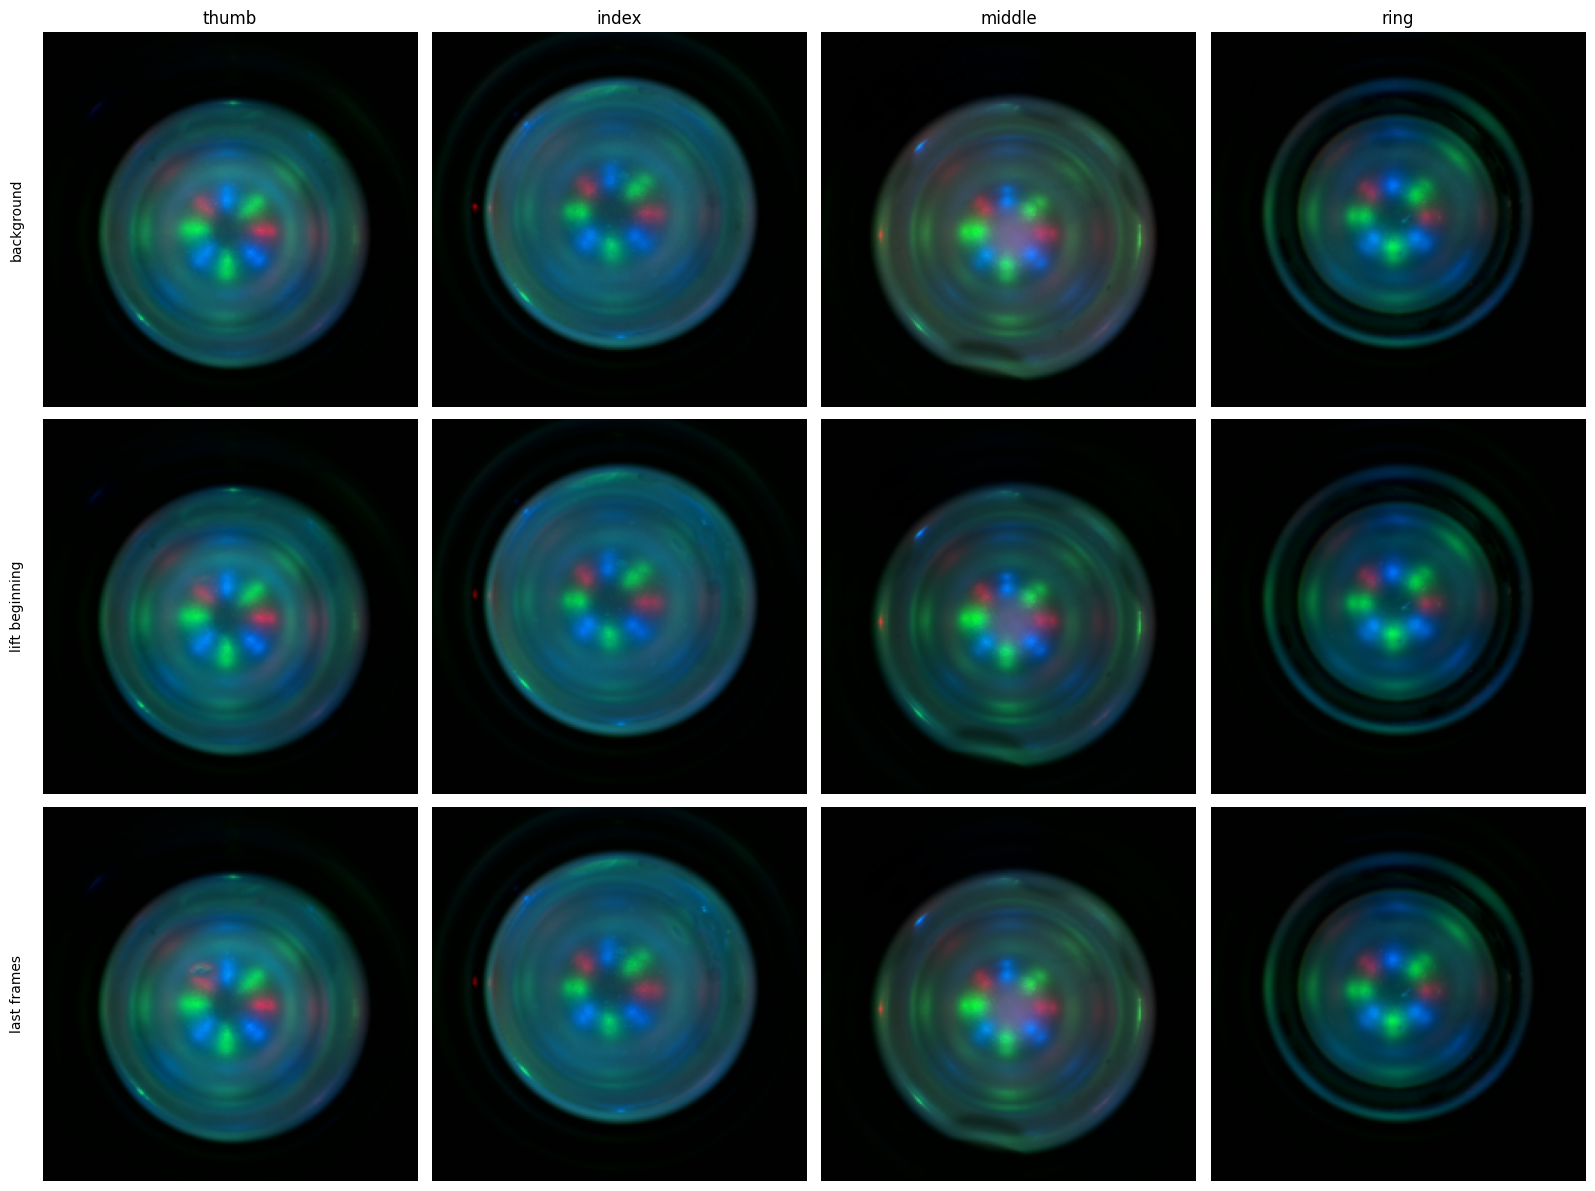

In [77]:
image_rows = {
    "background": finger_backgrounds,
    "lift beginning": finger_lift_beg_images,
    "last frames": finger_last_images,
}

preprocessed_finger_images = {
    row_name: {
        finger: preprocess_transform(images[finger])
        for finger in finger_names
    }
    for row_name, images in image_rows.items()
}

fig, axes = plt.subplots(
    len(image_rows),
    len(finger_names),
    figsize=(4 * len(finger_names), 4 * len(image_rows)),
    squeeze=False,
)
for row_idx, (row_name, images) in enumerate(preprocessed_finger_images.items()):
    for col_idx, finger in enumerate(finger_names):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[finger].permute(1, 2, 0))
        ax.axis("off")

        if row_idx == 0:
            ax.set_title(finger)
        if col_idx == 0:
            ax.text(
                -0.05, 0.5,
                row_name,
                transform=ax.transAxes,
                ha="right",
                va="center",
                rotation=90
            )

plt.tight_layout()